In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [5]:
df.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [6]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

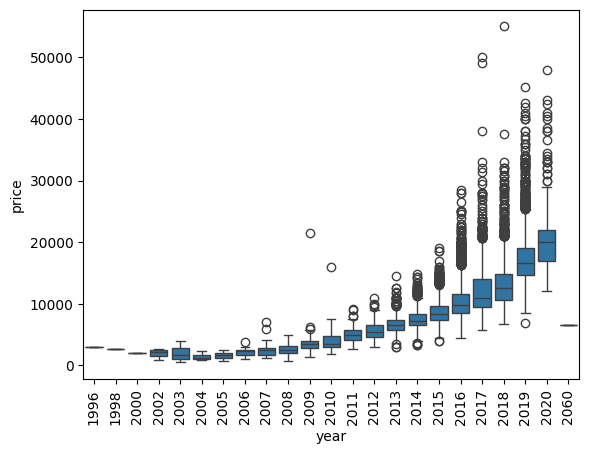

In [9]:
sns.boxplot(data=df, x = 'year', y = 'price')
plt.xticks(rotation = 90)

<Axes: xlabel='mileage', ylabel='price'>

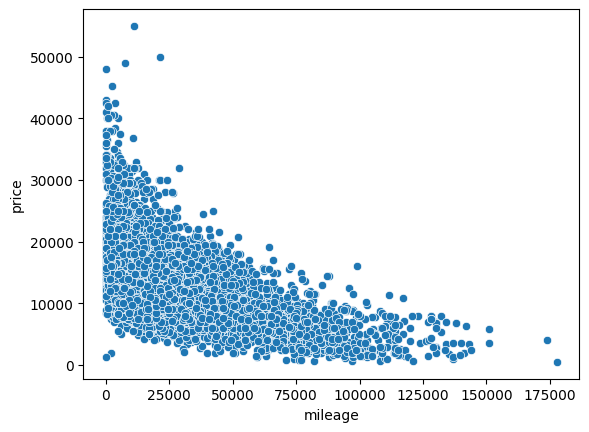

In [10]:
sns.scatterplot(data=df, x='mileage',y='price')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '1.1'),
  Text(3, 0, '1.2'),
  Text(4, 0, '1.3'),
  Text(5, 0, '1.4'),
  Text(6, 0, '1.5'),
  Text(7, 0, '1.6'),
  Text(8, 0, '1.7'),
  Text(9, 0, '1.8'),
  Text(10, 0, '2.0'),
  Text(11, 0, '2.2'),
  Text(12, 0, '2.3'),
  Text(13, 0, '2.5'),
  Text(14, 0, '3.2'),
  Text(15, 0, '5.0')])

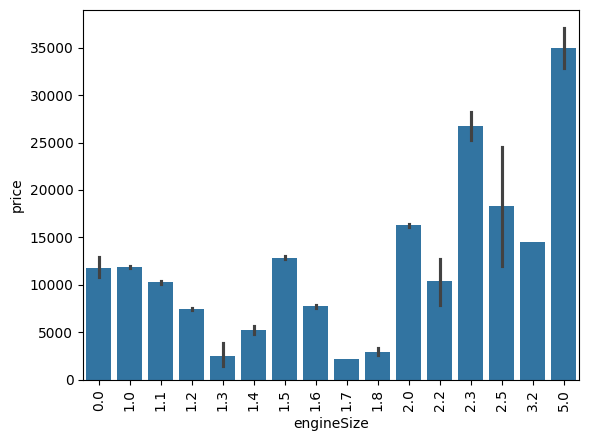

In [11]:
sns.barplot(data=df, x = 'engineSize', y = 'price')
plt.xticks(rotation = 90)

In [12]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

([0, 1, 2],
 [Text(0, 0, 'Automatic'), Text(1, 0, 'Manual'), Text(2, 0, 'Semi-Auto')])

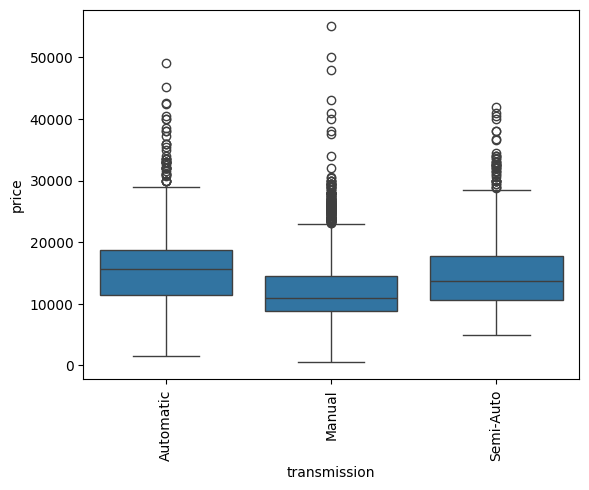

In [13]:
sns.boxplot(data=df, x = 'transmission', y = 'price')
plt.xticks(rotation = 90)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Petrol'),
  Text(1, 0, 'Diesel'),
  Text(2, 0, 'Hybrid'),
  Text(3, 0, 'Electric'),
  Text(4, 0, 'Other')])

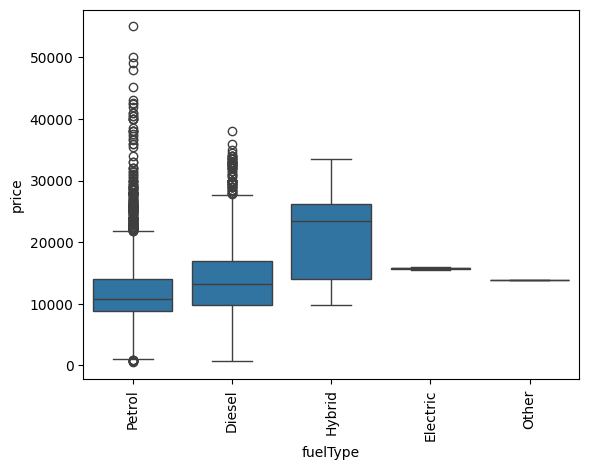

In [14]:
sns.boxplot(data=df, x = 'fuelType', y = 'price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

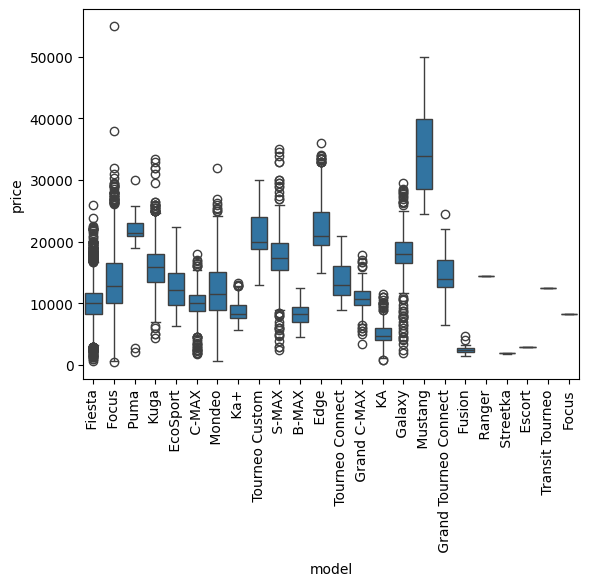

In [15]:
sns.boxplot(data=df, x = 'model', y = 'price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, '0'),
  Text(1, 0, '20'),
  Text(2, 0, '22'),
  Text(3, 0, '30'),
  Text(4, 0, '110'),
  Text(5, 0, '115'),
  Text(6, 0, '120'),
  Text(7, 0, '125'),
  Text(8, 0, '135'),
  Text(9, 0, '140'),
  Text(10, 0, '145'),
  Text(11, 0, '150'),
  Text(12, 0, '155'),
  Text(13, 0, '160'),
  Text(14, 0, '165'),
  Text(15, 0, '185'),
  Text(16, 0, '190'),
  Text(17, 0, '195'),
  Text(18, 0, '200'),
  Text(19, 0, '205'),
  Text(20, 0, '210'),
  Text(21, 0, '220'),
  Text(22, 0, '230'),
  Text(23, 0, '235'),
  Text(24, 0, '240'),
  Text(25, 0, '260'),
  Text(26, 0, '265'),
  Text(27, 0, '270'),
  Text(28, 0, '290'),
  Text(29, 0, '300'),
  Text(30, 0, '305'),
  Text(31, 0, '325'),
  Text(32, 0, '330'),
  Text(33, 0, '555'),
  Text(34, 0, '570'),
  Text(35, 0, '580')])

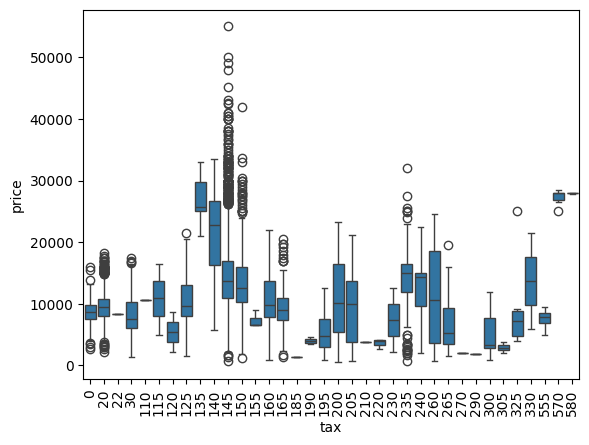

In [16]:
sns.boxplot(data=df, x = 'tax', y = 'price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89],
 [Text(0, 0, '20.8'),
  Text(1, 0, '20.9'),
  Text(2, 0, '22.1'),
  Text(3, 0, '22.6'),
  Text(4, 0, '22.8'),
  Text(5, 0, '23.5'),
  Text(6, 0, '23.7'),
  Text(7, 0, '23.9'),
  Text(8, 0, '24.8'),
  Text(9, 0, '26.3'),
  Text(10, 0, '27.4'),
  Text(11, 0, '28.0'),
  Text(12, 0, '28.3'),
  Text(13, 0, '28.5'),
  Text(14, 0, '28.8'),
  Text(15, 0, '29.1'),
  Text(16, 0, '29.4'),
  Text(17, 0, '30.1'),
  Text(18, 0, '30.4'),
  Text(19, 0, '30.7'),
  Text(20, 0, '31.0

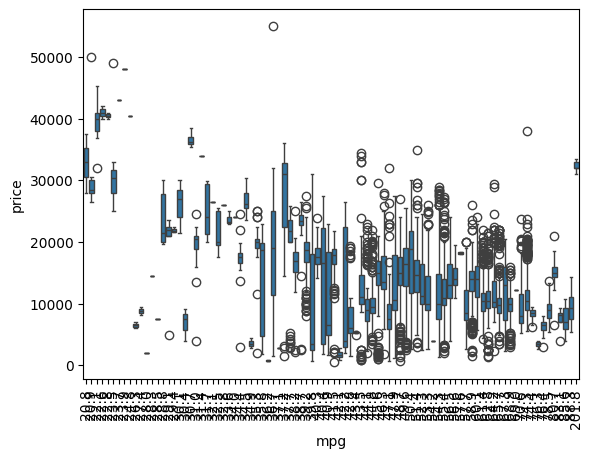

In [17]:
sns.boxplot(data=df, x = 'mpg', y = 'price')
plt.xticks(rotation = 90)

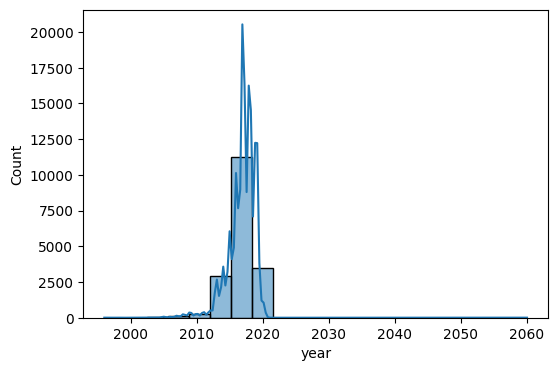

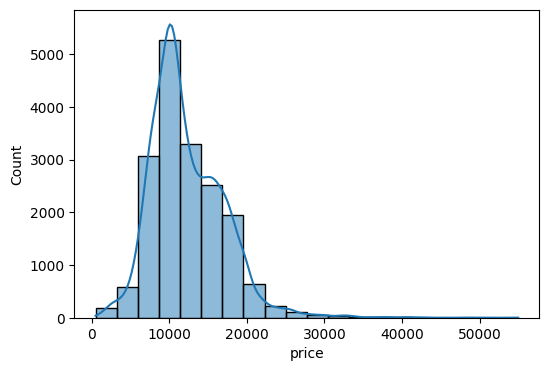

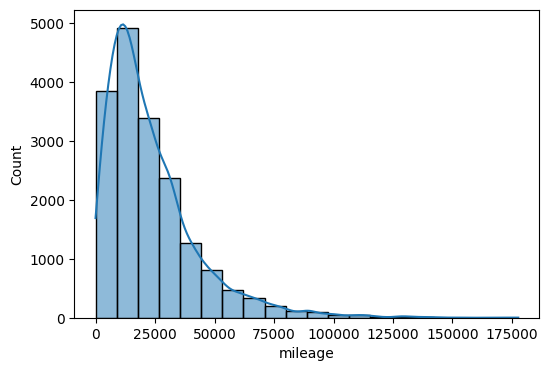

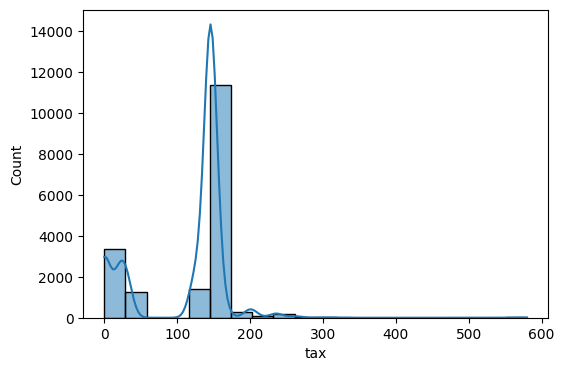

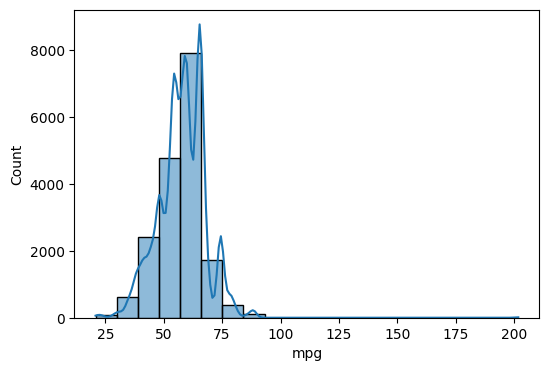

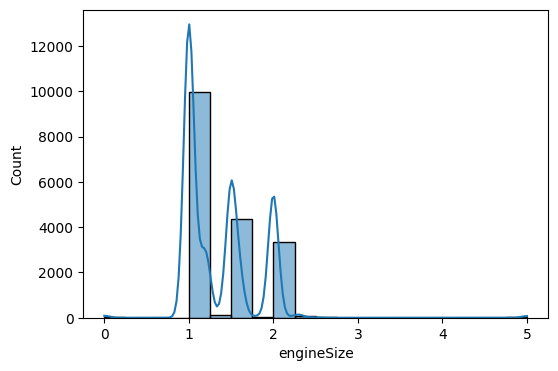

In [18]:
numeric_col = ['year', 'price', 'mileage', 'tax',
       'mpg', 'engineSize']
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='count', ylabel='model'>

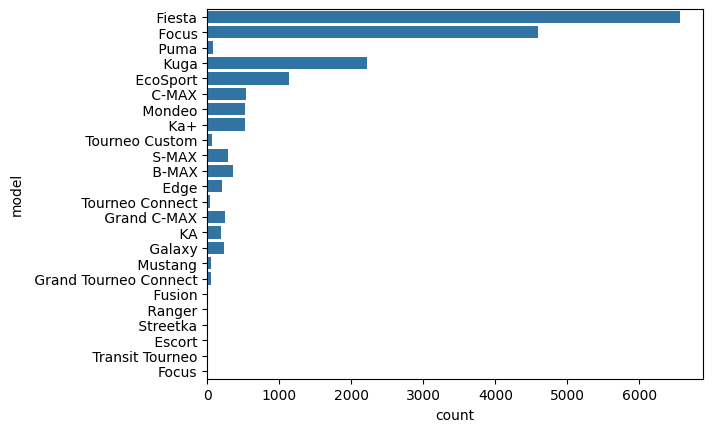

In [19]:
#plt.figure(figsize=(6,4))
sns.countplot(y = df['model'])

<Axes: xlabel='transmission', ylabel='count'>

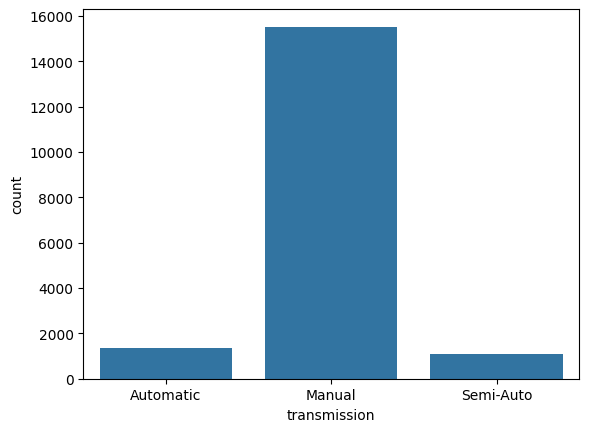

In [20]:
sns.countplot(x = df['transmission'])

<Axes: xlabel='fuelType', ylabel='count'>

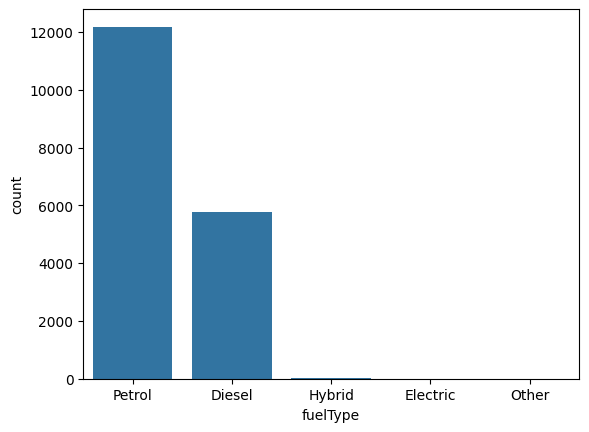

In [21]:
sns.countplot(x = df['fuelType'])

<Axes: >

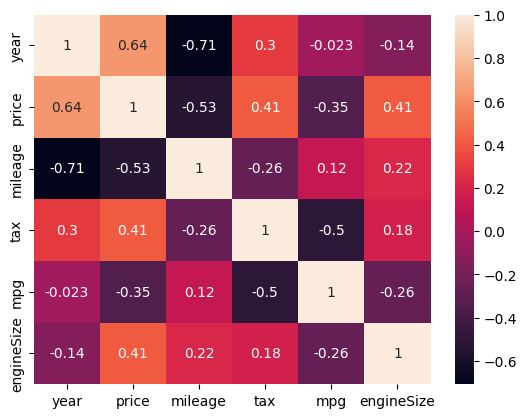

In [22]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

In [23]:
df.drop_duplicates(inplace = True)
X = df.drop(columns = ['price'], axis = 1)
y = df['price']

In [24]:
#df_clean = df.copy()
X.shape

(17812, 8)

In [25]:
X.shape

(17812, 8)

In [26]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [27]:
X_one_hot = pd.get_dummies(X,columns=['model','transmission','fuelType'],drop_first=True)
X_one_hot = X_one_hot.astype(int)
print(X_one_hot)
print(X_one_hot.columns)

       year  mileage  tax  mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0      2017    15944  150   57           1             0                0   
1      2018     9083  150   57           1             0                0   
2      2017    12456  150   57           1             0                0   
3      2019    10460  145   40           1             0                0   
4      2019     1482  145   48           1             0                0   
...     ...      ...  ...  ...         ...           ...              ...   
17961  2017    16700  150   47           1             0                0   
17962  2014    40700   30   57           1             0                0   
17963  2015     7010   20   67           1             0                0   
17964  2018     5007  145   57           1             0                0   
17965  2015     5007   22   57           1             0                0   

       model_ Edge  model_ Escort  model_ Fiesta  ...  model_ Tourneo Conne

In [28]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [29]:
from sklearn.preprocessing import LabelEncoder

columns = ['model','transmission','fuelType']

X_label = X.copy()
label_encoders = {}

for col in columns:
    encoder = LabelEncoder()
    X_label[col] = encoder.fit_transform(X_label[col].astype(str))
    label_encoders[col] = encoder
    
print(X_label)

       model  year  transmission  mileage  fuelType  tax   mpg  engineSize
0          5  2017             0    15944         4  150  57.7         1.0
1          6  2018             1     9083         4  150  57.7         1.0
2          6  2017             1    12456         4  150  57.7         1.0
3          5  2019             1    10460         4  145  40.3         1.5
4          5  2019             0     1482         4  145  48.7         1.0
...      ...   ...           ...      ...       ...  ...   ...         ...
17961      0  2017             1    16700         4  150  47.1         1.4
17962      0  2014             1    40700         4   30  57.7         1.0
17963      6  2015             1     7010         0   20  67.3         1.6
17964     11  2018             1     5007         4  145  57.7         1.2
17965     23  2015             1     5007         4   22  57.7         1.0

[17812 rows x 8 columns]


In [30]:
X_label['model'].value_counts()

model
5     6509
6     4555
13    2208
2     1127
1      542
12     523
14     512
0      350
18     294
9      247
8      227
3      205
11     197
16      79
21      69
15      57
10      57
20      32
7       16
19       2
17       1
4        1
22       1
23       1
Name: count, dtype: int64

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_col = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

X_one_hot = scaler.fit_transform(X_one_hot, numeric_col)

print(X_one_hot)

[[ 0.06705901 -0.38299351  0.59137991 ... -0.03516603 -0.007493
   0.68875341]
 [ 0.55439275 -0.73631699  0.59137991 ... -0.03516603 -0.007493
   0.68875341]
 [ 0.06705901 -0.56261635  0.59137991 ... -0.03516603 -0.007493
   0.68875341]
 ...
 [-0.90760848 -0.84307105 -1.50428354 ... -0.03516603 -0.007493
  -1.45189844]
 [ 0.55439275 -0.94622028  0.51077747 ... -0.03516603 -0.007493
   0.68875341]
 [-0.90760848 -0.94622028 -1.47204257 ... -0.03516603 -0.007493
   0.68875341]]


In [32]:
X_label.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [33]:
all_columns = ['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg','engineSize']
X_label[all_columns] = scaler.fit_transform(X_label,all_columns)
print(X_label)

          model      year  transmission   mileage  fuelType       tax  \
0     -0.460281  0.067059     -2.667947 -0.382994  0.688206  0.591380   
1     -0.210828  0.554393      0.042455 -0.736317  0.688206  0.591380   
2     -0.210828  0.067059      0.042455 -0.562616  0.688206  0.591380   
3     -0.460281  1.041726      0.042455 -0.665405  0.688206  0.510777   
4     -0.460281  1.041726     -2.667947 -1.127749  0.688206  0.510777   
...         ...       ...           ...       ...       ...       ...   
17961 -1.707547  0.067059      0.042455 -0.344061  0.688206  0.591380   
17962 -1.707547 -1.394942      0.042455  0.891875  0.688206 -1.343079   
17963 -0.210828 -0.907608      0.042455 -0.843071 -1.455326 -1.504284   
17964  1.036438  0.554393      0.042455 -0.946220  0.688206  0.510777   
17965  4.029875 -0.907608      0.042455 -0.946220  0.688206 -1.472043   

            mpg  engineSize  
0     -0.020597   -0.810561  
1     -0.020597   -0.810561  
2     -0.020597   -0.810561  
3  

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
X_train ,X_test ,y_train ,y_test = train_test_split(X_one_hot,y,test_size=0.33,random_state=42)
print(X_train)

[[ 0.55439275 -0.41852669  0.51077747 ... -0.03516603 -0.007493
   0.68875341]
 [-1.39494223  2.19475904  0.51077747 ... -0.03516603 -0.007493
   0.68875341]
 [ 1.0417265  -0.82890927  0.51077747 ... -0.03516603 -0.007493
   0.68875341]
 ...
 [-0.90760848  0.39482283 -1.82669331 ... -0.03516603 -0.007493
  -1.45189844]
 [-0.90760848  1.20894481  0.1883677  ... -0.03516603 -0.007493
   0.68875341]
 [ 0.55439275 -0.40997813  0.51077747 ... -0.03516603 -0.007493
   0.68875341]]


In [37]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)
y_pred

array([22211.67805925, 15037.33325529, 16540.89418284, ...,
       15095.04684122, 12870.16427509, 15253.28175323])

In [39]:
y_test

9891     22975
13006    18000
15284    18500
6399      9985
8182      7998
         ...  
12200    10470
7226     13998
11523    15199
13684    12290
9454     17990
Name: price, Length: 5878, dtype: int64

In [40]:
r2 = r2_score(y_test,y_pred)
r2

0.8310659101766336

In [41]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (((1-r2)*(n-1))/(n-p-1))
adjusted_r2

0.8300828947643463

In [42]:
X_train ,X_test ,y_train ,y_test = train_test_split(X_label,y,test_size=0.33,random_state=42)
print(X_train)

          model      year  transmission   mileage  fuelType       tax  \
6100  -0.210828  0.554393      0.042455 -0.418527  0.688206  0.510777   
14077 -0.460281 -1.394942      0.042455  2.194759  0.688206  0.510777   
12466 -0.210828  1.041726      0.042455 -0.828909  0.688206  0.510777   
8261   1.535344  1.041726      2.752856 -0.400400 -1.455326  0.510777   
13613  1.535344  1.041726      0.042455 -0.792140 -1.455326  0.510777   
...         ...       ...           ...       ...       ...       ...   
11406 -0.210828  0.554393      0.042455 -0.166705  0.688206  0.591380   
12096 -0.460281 -0.907608      0.042455  0.958565  0.688206  0.188368   
5418  -0.460281 -0.907608      0.042455  0.394823 -1.455326 -1.826693   
868   -0.460281 -0.907608      0.042455  1.208945  0.688206  0.188368   
15948 -0.210828  0.554393      0.042455 -0.409978  0.688206  0.510777   

            mpg  engineSize  
6100  -1.619427    1.501211  
14077 -0.987790    0.576502  
12466 -1.214784    0.345325  
826

In [43]:
model2 = LinearRegression()
model2.fit(X_train,y_train)

LinearRegression()

In [45]:
y_pred = model2.predict(X_test)
y_pred

array([16540.94185432, 15076.66531175, 16754.43591901, ...,
       13428.26494596, 13136.81760351, 13571.38462746])

In [46]:
y_test

9891     22975
13006    18000
15284    18500
6399      9985
8182      7998
         ...  
12200    10470
7226     13998
11523    15199
13684    12290
9454     17990
Name: price, Length: 5878, dtype: int64

In [47]:
r2 = r2_score(y_test,y_pred)
r2

0.7167444123752094

In [48]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (((1-r2)*(n-1))/(n-p-1))
adjusted_r2

0.7163583083198339